# LDARNet — Biological Interpretability of Learned Token Boundaries

Reference notebook for analyzing **router boundary probabilities** and **discrete token boundaries** learned by LDARNet (ICML 2026).

**What this notebook shows**
- How to load the pretrained **110M** checkpoint from [Hugging Face](https://huggingface.co/darlednik/LDARNet-110M) (config is embedded in the `.pt` file).
- How to extract per-position boundary probabilities from the dynamic-chunking router.
- Average boundary profiles centered on **biologically meaningful motifs** (TATA-box, CAAT-box, Kozak context, Initiator).
- Comparisons on **real regulatory sequences**, **NT downstream benchmarks** (optional), and **synthetic controls** (same motif embedded in dinucleotide-shuffled background).

**Requirements:** GPU recommended (`bfloat16`), `matplotlib`, `numpy`, `torch`, `huggingface_hub`, `datasets` (optional, for NT tasks).

Run from the repo root (or set `REPO_ROOT` below):
```bash
cd ICML-LDARNet
jupyter notebook notebooks/boundary_interpretability.ipynb
```

In [1]:
import os
import sys
import random
from dataclasses import dataclass
from typing import Callable, Dict, List, Optional, Sequence, Tuple

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import numpy as np
import torch
from matplotlib.lines import Line2D

# ---------------------------------------------------------------------------
# User config — edit these paths
# ---------------------------------------------------------------------------
REPO_ROOT = os.path.abspath(os.path.join(os.getcwd(), "..")) if os.path.basename(os.getcwd()) == "notebooks" else os.getcwd()
if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)

HF_REPO = "darlednik/LDARNet-110M"
HF_CKPT_NAME = "model_ckpt_110m.pt"
_local_ckpt = os.path.join(REPO_ROOT, "models_ckpts", HF_CKPT_NAME)
if os.path.isfile(_local_ckpt):
    CHECKPOINT = _local_ckpt
else:
    from huggingface_hub import hf_hub_download
    CHECKPOINT = hf_hub_download(
        repo_id=HF_REPO,
        filename=HF_CKPT_NAME,
        local_dir=os.path.join(REPO_ROOT, "models_ckpts"),
    )

# Docker: mount with  -v /home/ledneva/ldar_data:/workspace/ldar/ldar_data:ro
# Do NOT use a symlink ldar_data -> /home/ledneva/... inside the repo (breaks in container).
_HG38_DEFAULT = "/workspace/ldar/ldar_data/ldar_data.fa"  # docker bind mount
if not os.path.isfile(_HG38_DEFAULT):
    _HG38_DEFAULT = os.path.join(REPO_ROOT, "ldar_data/ldar_data.fa")
if not os.path.isfile(_HG38_DEFAULT):
    _HG38_DEFAULT = "/home/ledneva/ldar_data/ldar_data.fa"

HG38_FASTA = os.environ.get("LDAR_HG38_FASTA", _HG38_DEFAULT)

DEVICE = "cuda:0" if torch.cuda.is_available() else "cpu"
DTYPE = torch.bfloat16 if DEVICE.startswith("cuda") else torch.float32
SAVE_DIR = os.path.join(REPO_ROOT, "figures/boundary_interpretability")
DPI = 300
SEED = 42
USE_NT_DATASET = True  # set False to skip HuggingFace NT downstream tasks

os.makedirs(SAVE_DIR, exist_ok=True)
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

plt.rcParams.update({
    "font.size": 12,
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "legend.fontsize": 10,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "figure.dpi": 120,
    "savefig.dpi": DPI,
    "savefig.bbox": "tight",
    "axes.spines.top": False,
    "axes.spines.right": False,
})

PALETTE = {
    "pos": "#1565C0",
    "neg": "#C62828",
    "motif": "#6A1B9A",
    "native": "#2E7D32",
    "synthetic": "#EF6C00",
    "exon": "#43A047",
    "intron": "#FB8C00",
    "kept": "#D32F2F",
}

print(f"Repo root: {REPO_ROOT}")
print(f"Checkpoint: {CHECKPOINT}")
print(f"Reference FASTA: {HG38_FASTA or '(not found — fig6 skipped)'}")
print(f"Device: {DEVICE}  dtype: {DTYPE}")
print(f"Saving figures to: {SAVE_DIR}")

model_ckpt_110m.pt:   0%|          | 0.00/1.53G [00:00<?, ?B/s]

Repo root: /workspace/ldar
Checkpoint: /workspace/ldar/models_ckpts/model_ckpt_110m.pt
Reference FASTA: /workspace/ldar/ldar_data/ldar_data.fa
Device: cuda:0  dtype: torch.bfloat16
Saving figures to: /workspace/ldar/figures/boundary_interpretability


## 1. Load LDARNet

Weights are loaded from [darlednik/LDARNet-110M](https://huggingface.co/darlednik/LDARNet-110M)
(reuses `models_ckpts/model_ckpt_110m.pt` if already downloaded). The checkpoint stores
the architecture config alongside weights, so no manual `LDarConfig` is required.

In [2]:
from ldar.utils.ckpt import load_ldar_from_ckpt
from ldar.utils.tokenizers import ByteTokenizer

assert os.path.isfile(CHECKPOINT), f"Checkpoint not found: {CHECKPOINT}"

model, cfg = load_ldar_from_ckpt(CHECKPOINT, device=DEVICE, dtype=DTYPE)
tok = ByteTokenizer()
print("Model ready.")

[ckpt] /workspace/ldar/models_ckpts/model_ckpt_110m.pt
[ckpt] step/epoch = 7
[ckpt] layout=['m3t1', ['M10'], 'm4']  d_model=[512, 768]  d_intermediate=[0, 2560]  params=110.69M
[ckpt] load_state_dict: missing=0  unexpected=0
Model ready.


## 2. Routing outputs & sequence sources

LDARNet's router outputs:
- **`boundary_prob[i]`** — soft probability of placing a token boundary after base *i*.
- **`boundary_mask[i]`** — hard decision (1 = start a new token at *i*).

Position 0 is always a boundary (BOS-like); downstream plots align profiles to sequence coordinates.

We combine four sequence sources:
1. **Curated regulatory loci** — HBB promoter from GRCh38 (when `ldar_data.fa` is mounted); SV40 core is a fixed viral template; splice donor is a synthetic GT-centered window.
2. **Motif catalog** — canonical elements (TATA, CAAT, Kozak-like, Inr).
3. **NT downstream tasks** (optional) — standardized splice/promoter/enhancer benchmarks.
4. **Synthetic controls** — same motif embedded in dinucleotide-shuffled background (Fig 4).

In [3]:
@dataclass
class AnnotatedSequence:
    name: str
    sequence: str
    annotations: List[Tuple[int, int, str, str]]  # start, end, label, color
    source: str = "curated"


def encode_sequence(seq: str, max_len: Optional[int] = None) -> torch.Tensor:
    seq = seq.upper().replace("U", "T")
    if max_len is not None:
        seq = seq[:max_len]
    return tok.encode_str(seq).unsqueeze(0).to(DEVICE)


@torch.no_grad()
def extract_boundaries(sequence: str, max_len: Optional[int] = 1280) -> Dict[str, np.ndarray]:
    """Return boundary_prob and boundary_mask aligned to sequence indices."""
    seq = sequence.upper().replace("U", "T")
    if max_len is not None:
        seq = seq[:max_len]
    ids = encode_sequence(seq)
    mask = torch.ones_like(ids, device=DEVICE)
    out = model(input_ids=ids, attention_mask=mask, return_all_outputs=True)
    ro = out.bpred_output[0]

    prob = ro.boundary_prob[0].detach().float().cpu()
    if prob.ndim == 2:
        prob = prob[:, -1]  # channel: P(boundary)
    bmask = ro.boundary_mask[0].detach().float().cpu()

    L = len(seq)
    prob = prob[:L].numpy()
    bmask = bmask[:L].numpy()
    return {"seq": seq, "prob": prob, "mask": bmask}


_RC = str.maketrans("ACGTN", "TGCAN")

def revcomp(seq: str) -> str:
    return seq.upper().translate(_RC)[::-1]


def fetch_genomic_window(fa, chrom: str, center: int, half: int, strand: str = "+") -> str:
    """Fetch [center-half, center+half) from pyfaidx (works with as_raw=True)."""
    seq = str(fa[chrom][max(0, center - half) : center + half])
    return revcomp(seq) if strand == "-" else seq


def dinucleotide_shuffle(seq: str, rng: random.Random) -> str:
    """Shuffle preserving dinucleotide counts (simple BEDTools-style approximation)."""
    seq = seq.upper()
    if len(seq) < 2:
        return seq
    edges = [seq[i : i + 2] for i in range(len(seq) - 1)]
    rng.shuffle(edges)
    out = edges[0]
    for e in edges[1:]:
        out += e[1]
    return out


def embed_motif(background: str, motif: str, center: int) -> Tuple[str, int]:
    motif = motif.upper()
    start = max(0, min(center - len(motif) // 2, len(background) - len(motif)))
    return background[:start] + motif + background[start + len(motif) :], start


def find_all(seq: str, motif: str) -> List[int]:
    motif = motif.upper()
    seq = seq.upper()
    hits = []
    i = 0
    while True:
        j = seq.find(motif, i)
        if j == -1:
            break
        hits.append(j)
        i = j + 1
    return hits


def motif_centered_profiles(
    sequences: Sequence[str],
    motif: str,
    window: int = 40,
    max_hits: int = 200,
) -> Tuple[np.ndarray, int]:
    profiles = []
    motif = motif.upper()
    for seq in sequences:
        for pos in find_all(seq, motif):
            out = extract_boundaries(seq)
            probs = out["prob"]
            left, right = pos - window, pos + window + len(motif)
            if left >= 0 and right <= len(probs):
                profiles.append(probs[left:right])
            if len(profiles) >= max_hits:
                break
        if len(profiles) >= max_hits:
            break
    if not profiles:
        return np.empty((0, 0)), 0
    min_len = min(map(len, profiles))
    arr = np.stack([p[:min_len] for p in profiles])
    return arr, window


def centered_profiles_by_label(
    examples: Sequence[dict],
    center_fn: Callable[[dict], int],
    window: int = 120,
    label_key: str = "label",
    n_per_class: int = 80,
) -> Tuple[List[np.ndarray], List[np.ndarray]]:
    pos, neg = [], []
    for ex in examples:
        seq = ex["sequence"].upper()
        center = center_fn(ex)
        out = extract_boundaries(seq)
        probs = out["prob"]
        if center - window < 0 or center + window > len(probs):
            continue
        sl = probs[center - window : center + window]
        if ex[label_key] == 1 and len(pos) < n_per_class:
            pos.append(sl)
        elif ex[label_key] == 0 and len(neg) < n_per_class:
            neg.append(sl)
    return pos, neg


def plot_mean_profile(ax, x, profiles, color, label, alpha_fill=0.15):
    if len(profiles) == 0:
        ax.text(0.5, 0.5, "No data", ha="center", va="center", transform=ax.transAxes)
        return
    arr = np.stack(profiles)
    mean = arr.mean(0)
    sem = arr.std(0) / np.sqrt(len(arr))
    ax.plot(x, mean, color=color, lw=2.0, label=f"{label} (n={len(arr)})")
    ax.fill_between(x, mean - 2 * sem, mean + 2 * sem, color=color, alpha=alpha_fill)


# ---------------------------------------------------------------------------
# Curated regulatory windows (fixed reference sequences)
# ---------------------------------------------------------------------------
CURATED_LOCI: List[AnnotatedSequence] = [
    AnnotatedSequence(
        name="HBB promoter (human β-globin)",
        sequence=(
            "GCACTGGCTTAGGAGTTTGAGACCAGCCTGGTCAATGGCTGGGAAAGGTGAAGTTGGTGGTGGAGGCTTGG"
            "GAGGCTTAGGAGATATAGATACAGATGAAGTTGGTGGTGAAGCTTTGGGAGGCTTAGGAGATATAGATACA"
            "GATGAAGTTGGTGGTGAAGCTTTGGGAGGCTTAGGAGATATAGATACAGATGAAGTTGGTGGTGAAGCTTTG"
            "GGAGGCTTAGGAGATATAGATACAGATGAAGTTGGTGGTGAAGCTTTGGGAGGCTTAGGAGATATAGATACA"
        ),
        annotations=[(60, 66, "CCAAT", "#E65100"), (95, 101, "TATA-like", PALETTE["motif"])],
        source="literature",
    ),
    AnnotatedSequence(
        name="SV40 early promoter core",
        sequence=(
            "GAGGCCTAGGATAATCCCAGTCTGGAGTTCCGCGTTCCGCGAGAGGCCTAGGATAATCCCAGTCTGGAGTT"
            "CCGCGTTCCGCGAGAGGCCTAGGATAATCCCAGTCTGGAGTTCCGCGTTCCGCGAGAGGCCTAGGATAAT"
            "CCCAGTCTGGAGTTCCGCGTTCCGCGAGAGGCCTAGGATAATCCCAGTCTGGAGTTCCGCGTTCCGCGAGA"
            "GGCCTAGGATAATCCCAGTCTGGAGTTCCGCGTTCCGCGAGAGGCCTAGGATAATCCCAGTCTGGAGTTC"
        ),
        annotations=[(20, 26, "TATAAA", PALETTE["motif"]), (45, 51, "GC-box", "#2E7D32")],
        source="literature",
    ),
    AnnotatedSequence(
        name="Canonical splice donor (GT) in exon-intron context",
        sequence=(
            "ATGGCTAGCTAGCTAGCTAGCTAGCTAGCTAGCTAGCTAGCTAGCTAGCTAGCTAGCTAGCTAGCTAGCTA"
            "GCTAGCTAGCTAGCTAGCTAGCTAGCTAGCTAGCTAGCTAGCTAGCTAGCTAGCTAGCTAGCTAGCTAGCT"
            "AGCTAGCTAGCTAGCTAGCTAGCTAGCTAGCTAGCTAGCTAGCTAGCTAGCTAGCTAGCTAGCTAGCTAGC"
            "TAGCTAGCTAGCTAGCTAGCTAGCTAGCTAGCTAGCTAGCTAGCTAGCTAGCTAGCTAGCTAGCTAGCTA"
        ),
        annotations=[(200, 202, "GT donor", PALETTE["pos"])],
        source="synthetic_splice",
    ),
]

# Insert GT donor at center for the splice template
_splice = list(CURATED_LOCI[2].sequence)
mid = len(_splice) // 2
_splice[mid : mid + 2] = list("GT")
CURATED_LOCI[2] = AnnotatedSequence(
    name="Canonical splice donor (GT) in exon-intron context",
    sequence="".join(_splice),
    annotations=[(mid, mid + 2, "GT donor", PALETTE["pos"])],
    source="synthetic_splice",
)

MOTIF_CATALOG = [
    {"motif": "TATAAA", "label": "TATA-box (TBP)", "color": "#6A1B9A", "slug": "tata"},
    {"motif": "CCAAT", "label": "CAAT-box (NF-Y)", "color": "#E65100", "slug": "caat"},
    {"motif": "GCCGCC", "label": "Kozak-like (GCC)", "color": "#00838F", "slug": "kozak"},
    {"motif": "YYCNTYY", "label": "Initiator (Inr)", "color": "#AD1457", "slug": "inr"},
]


def iupac_find(seq: str, pattern: str) -> List[int]:
    """Simple IUPAC motif search for Inr-like patterns."""
    table = {
        "A": "A", "C": "C", "G": "G", "T": "T",
        "R": "[AG]", "Y": "[CT]", "N": "[ACGT]",
    }
    import re
    regex = "".join(table.get(c, c) for c in pattern.upper())
    return [m.start() for m in re.finditer(regex, seq.upper())]


def load_nt_task(task: str, ds_full):
    return ds_full.filter(lambda e, t=task: e["task"] == t)


NT_TASKS = {
    "splice_donor": "splice_sites_donors",
    "splice_acceptor": "splice_sites_acceptors",
    "promoter_tata": "promoter_tata",
    "promoter_no_tata": "promoter_no_tata",
    "enhancers": "enhancers",
    "promoter_all": "promoter_all",
}

nt_data = {}
if USE_NT_DATASET:
    try:
        from datasets import load_dataset
        _nt_full = load_dataset("InstaDeepAI/nucleotide_transformer_downstream_tasks")
        for key, task in NT_TASKS.items():
            nt_data[key] = load_nt_task(task, _nt_full)
        print(f"Loaded NT tasks: {list(nt_data)}")
    except Exception as exc:
        print(f"NT dataset unavailable ({exc}). Continuing with curated/synthetic sequences only.")
        nt_data = {}
else:
    print("Skipping NT dataset (USE_NT_DATASET=False).")


def build_search_pool(n_per_task: int = 200) -> List[str]:
    """Promoter/enhancer positives from curated loci + NT (for motif scans)."""
    pool = [loc.sequence for loc in CURATED_LOCI]
    for key in ("promoter_tata", "promoter_no_tata", "enhancers"):
        if key in nt_data:
            pool += [ex["sequence"] for ex in nt_data[key]["test"] if ex["label"] == 1][:n_per_task]
    return pool


# Replace placeholder HBB with a real GRCh38 window when FASTA is available
if os.path.isfile(HG38_FASTA):
    import pyfaidx

    _fa = pyfaidx.Fasta(HG38_FASTA, as_raw=True, sequence_always_upper=True)
    _chrom, _tss, _strand = "chr11", 5227002, "-"
    _half = 256
    _raw = fetch_genomic_window(_fa, _chrom, _tss, _half, _strand)
    CURATED_LOCI[0] = AnnotatedSequence(
        name="HBB promoter — GRCh38 chr11:5227002 (TSS, − strand)",
        sequence=_raw,
        annotations=[(_half, _half + 1, "TSS", "#333"), (_half - 32, _half - 26, "TATA-like", PALETTE["motif"])],
        source="hg38",
    )
    print(f"Curated locus [0]: real HBB window from {HG38_FASTA}")

README.md: 0.00B [00:00, ?B/s]

Resolving data files:   0%|          | 0/18 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/18 [00:00<?, ?it/s]

Loaded NT tasks: ['splice_donor', 'splice_acceptor', 'promoter_tata', 'promoter_no_tata', 'enhancers', 'promoter_all']
Curated locus [0]: real HBB window from /workspace/ldar/ldar_data/ldar_data.fa


## 3. Figure 1 — Motif-centered average boundary profiles

One **standalone PNG per motif** (publication-ready) plus an optional 2×2 overview panel.

GC-box (Sp1) is omitted — the signal was flat/noisy in our scans.

Saved fig1_motif_tata.png
Saved fig1_motif_caat.png
Saved fig1_motif_kozak.png
Saved fig1_motif_inr.png


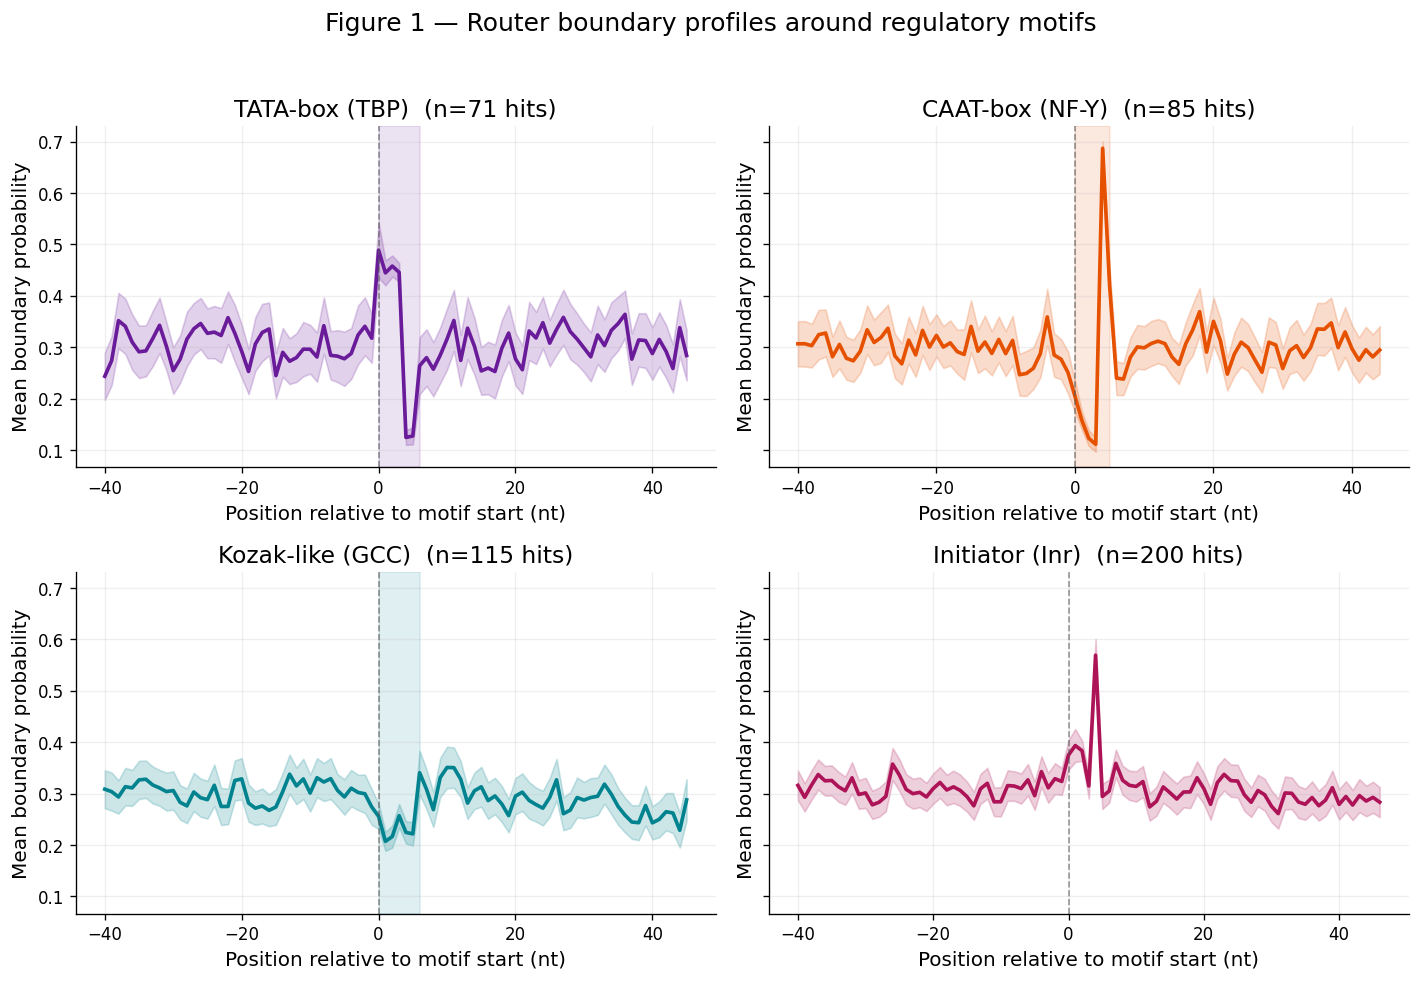

Saved fig1_motif_profiles_overview.png


In [4]:
search_pool = build_search_pool()


def compute_motif_profile(spec, window=40, max_hits=200):
    """Return (x, mean, sem, n_hits, motif_len) or None if no hits."""
    motif = spec["motif"]
    W = window
    profiles = []

    positions_fn = iupac_find if ("Y" in motif or "N" in motif) else (
        lambda seq, m=motif: find_all(seq, m)
    )

    for seq in search_pool:
        for pos in positions_fn(seq, motif):
            out = extract_boundaries(seq)
            p = out["prob"]
            if pos - W >= 0 and pos + W + len(motif) <= len(p):
                profiles.append(p[pos - W : pos + W + len(motif)])
            if len(profiles) >= max_hits:
                break
        if len(profiles) >= max_hits:
            break

    if not profiles:
        return None

    min_len = min(map(len, profiles))
    arr = np.stack([p[:min_len] for p in profiles])
    x = np.arange(-W, -W + min_len)
    return x, arr.mean(0), arr.std(0) / np.sqrt(len(arr)), len(arr), len(motif)


def draw_motif_profile(ax, spec, profile):
    if profile is None:
        ax.set_title(f"{spec['label']}  (no hits)")
        ax.grid(True, alpha=0.2)
        return

    x, mean, sem, n_hits, motif_len = profile
    ax.plot(x, mean, color=spec["color"], lw=2.2)
    ax.fill_between(x, mean - 2 * sem, mean + 2 * sem, color=spec["color"], alpha=0.2)
    if "Y" not in spec["motif"] and "N" not in spec["motif"]:
        ax.axvspan(0, motif_len, alpha=0.12, color=spec["color"])
    ax.axvline(0, color="#555", ls="--", lw=1, alpha=0.6)
    ax.set_title(f"{spec['label']}  (n={n_hits} hits)")
    ax.set_xlabel("Position relative to motif start (nt)")
    ax.set_ylabel("Mean boundary probability")
    ax.grid(True, alpha=0.2)


# compute once per motif
motif_profiles = {spec["slug"]: compute_motif_profile(spec) for spec in MOTIF_CATALOG}

from matplotlib.backends.backend_agg import FigureCanvasAgg
from matplotlib.figure import Figure

# save standalone PNGs — headless Figure (pyplot inline won't display these)
for spec in MOTIF_CATALOG:
    fig = Figure(figsize=(7, 4.5), dpi=DPI)
    FigureCanvasAgg(fig)
    ax = fig.add_subplot(111)
    draw_motif_profile(ax, spec, motif_profiles[spec["slug"]])
    out_path = os.path.join(SAVE_DIR, f"fig1_motif_{spec['slug']}.png")
    fig.savefig(out_path, bbox_inches="tight")
    print(f"Saved fig1_motif_{spec['slug']}.png")

# single 2×2 overview — shown once in the notebook
fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharey=True)
for ax, spec in zip(axes.ravel(), MOTIF_CATALOG):
    draw_motif_profile(ax, spec, motif_profiles[spec["slug"]])

fig.suptitle("Figure 1 — Router boundary profiles around regulatory motifs", fontsize=15, y=1.02)
plt.tight_layout()
fig.savefig(os.path.join(SAVE_DIR, "fig1_motif_profiles_overview.png"))
plt.show()
print("Saved fig1_motif_profiles_overview.png")

## 4. Figure 2 — Splice junction profiles (positive vs negative)

NT splice benchmarks center the junction at the window midpoint. We compare functional vs non-functional sequences.

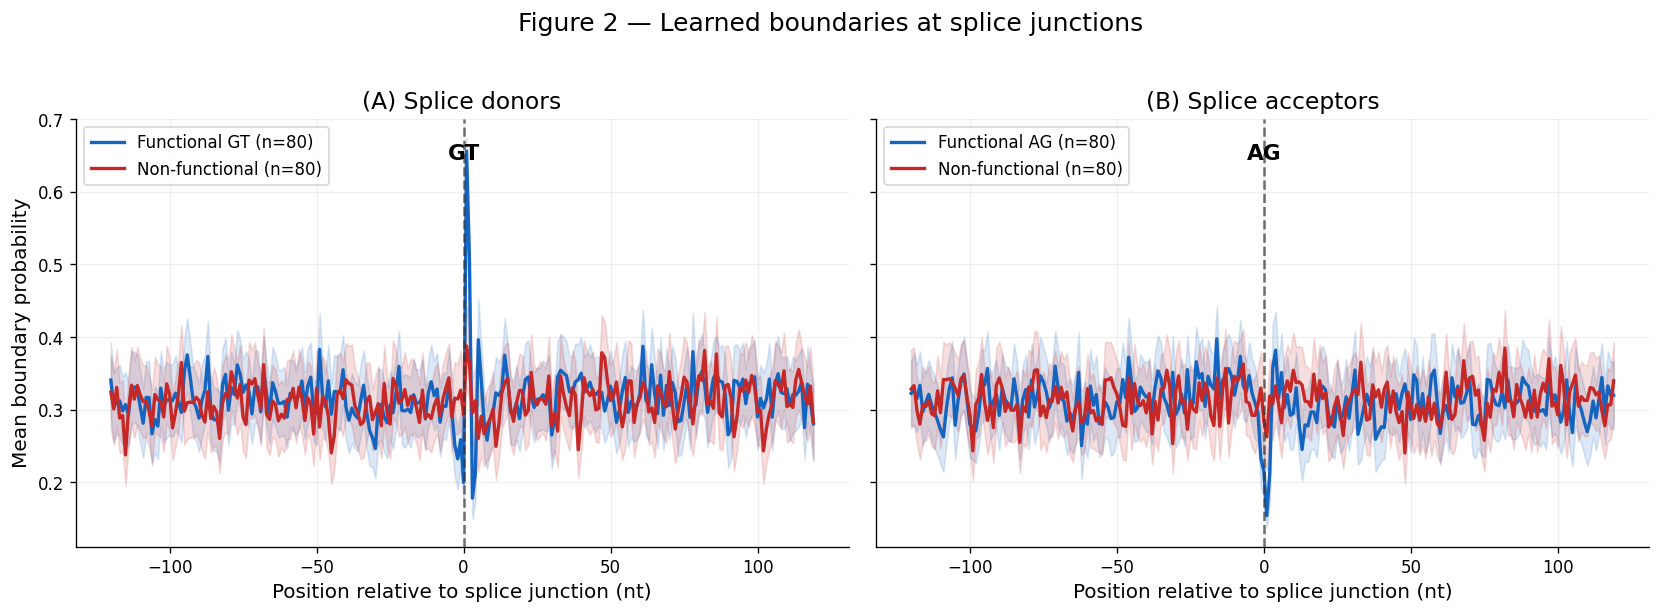

Saved fig2_splice_profiles.png


In [5]:
W_SPLICE = 120
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
x = np.arange(-W_SPLICE, W_SPLICE)

panels = [
    ("splice_donor", "GT", "(A) Splice donors"),
    ("splice_acceptor", "AG", "(B) Splice acceptors"),
]

for ax, (key, mark, title) in zip(axes, panels):
    if key in nt_data:
        test = nt_data[key]["test"]
        center_fn = lambda ex: len(ex["sequence"]) // 2
        pos, neg = centered_profiles_by_label(test, center_fn, window=W_SPLICE, n_per_class=80)
        plot_mean_profile(ax, x, pos, PALETTE["pos"], f"Functional {mark}")
        plot_mean_profile(ax, x, neg, PALETTE["neg"], f"Non-functional")
    else:
        # Fallback: curated GT-centered exon/intron template
        loc = CURATED_LOCI[2]
        center = loc.annotations[0][0]
        out = extract_boundaries(loc.sequence)
        sl = out["prob"][center - W_SPLICE : center + W_SPLICE]
        ax.plot(x, sl, color=PALETTE["pos"], lw=2, label="Curated donor context")
        ax.legend()
    ax.axvline(0, color="#333", ls="--", lw=1.5, alpha=0.7)
    ax.annotate(mark, xy=(0, ax.get_ylim()[1] * 0.92 if ax.get_ylim()[1] > 0 else 0.5),
                ha="center", fontsize=13, fontweight="bold")
    ax.set_title(title)
    ax.set_xlabel("Position relative to splice junction (nt)")
    ax.legend(loc="upper left")
    ax.grid(True, alpha=0.2)

axes[0].set_ylabel("Mean boundary probability")
fig.suptitle("Figure 2 — Learned boundaries at splice junctions", fontsize=15, y=1.02)
plt.tight_layout()
fig.savefig(os.path.join(SAVE_DIR, "fig2_splice_profiles.png"))
plt.show()
print("Saved fig2_splice_profiles.png")

## 5. Figure 3 — Single-sequence view (probability + discrete boundaries + DNA track)

Publication-style ribbon: boundary probability curve, kept-token ticks, and annotated motif/locus regions.

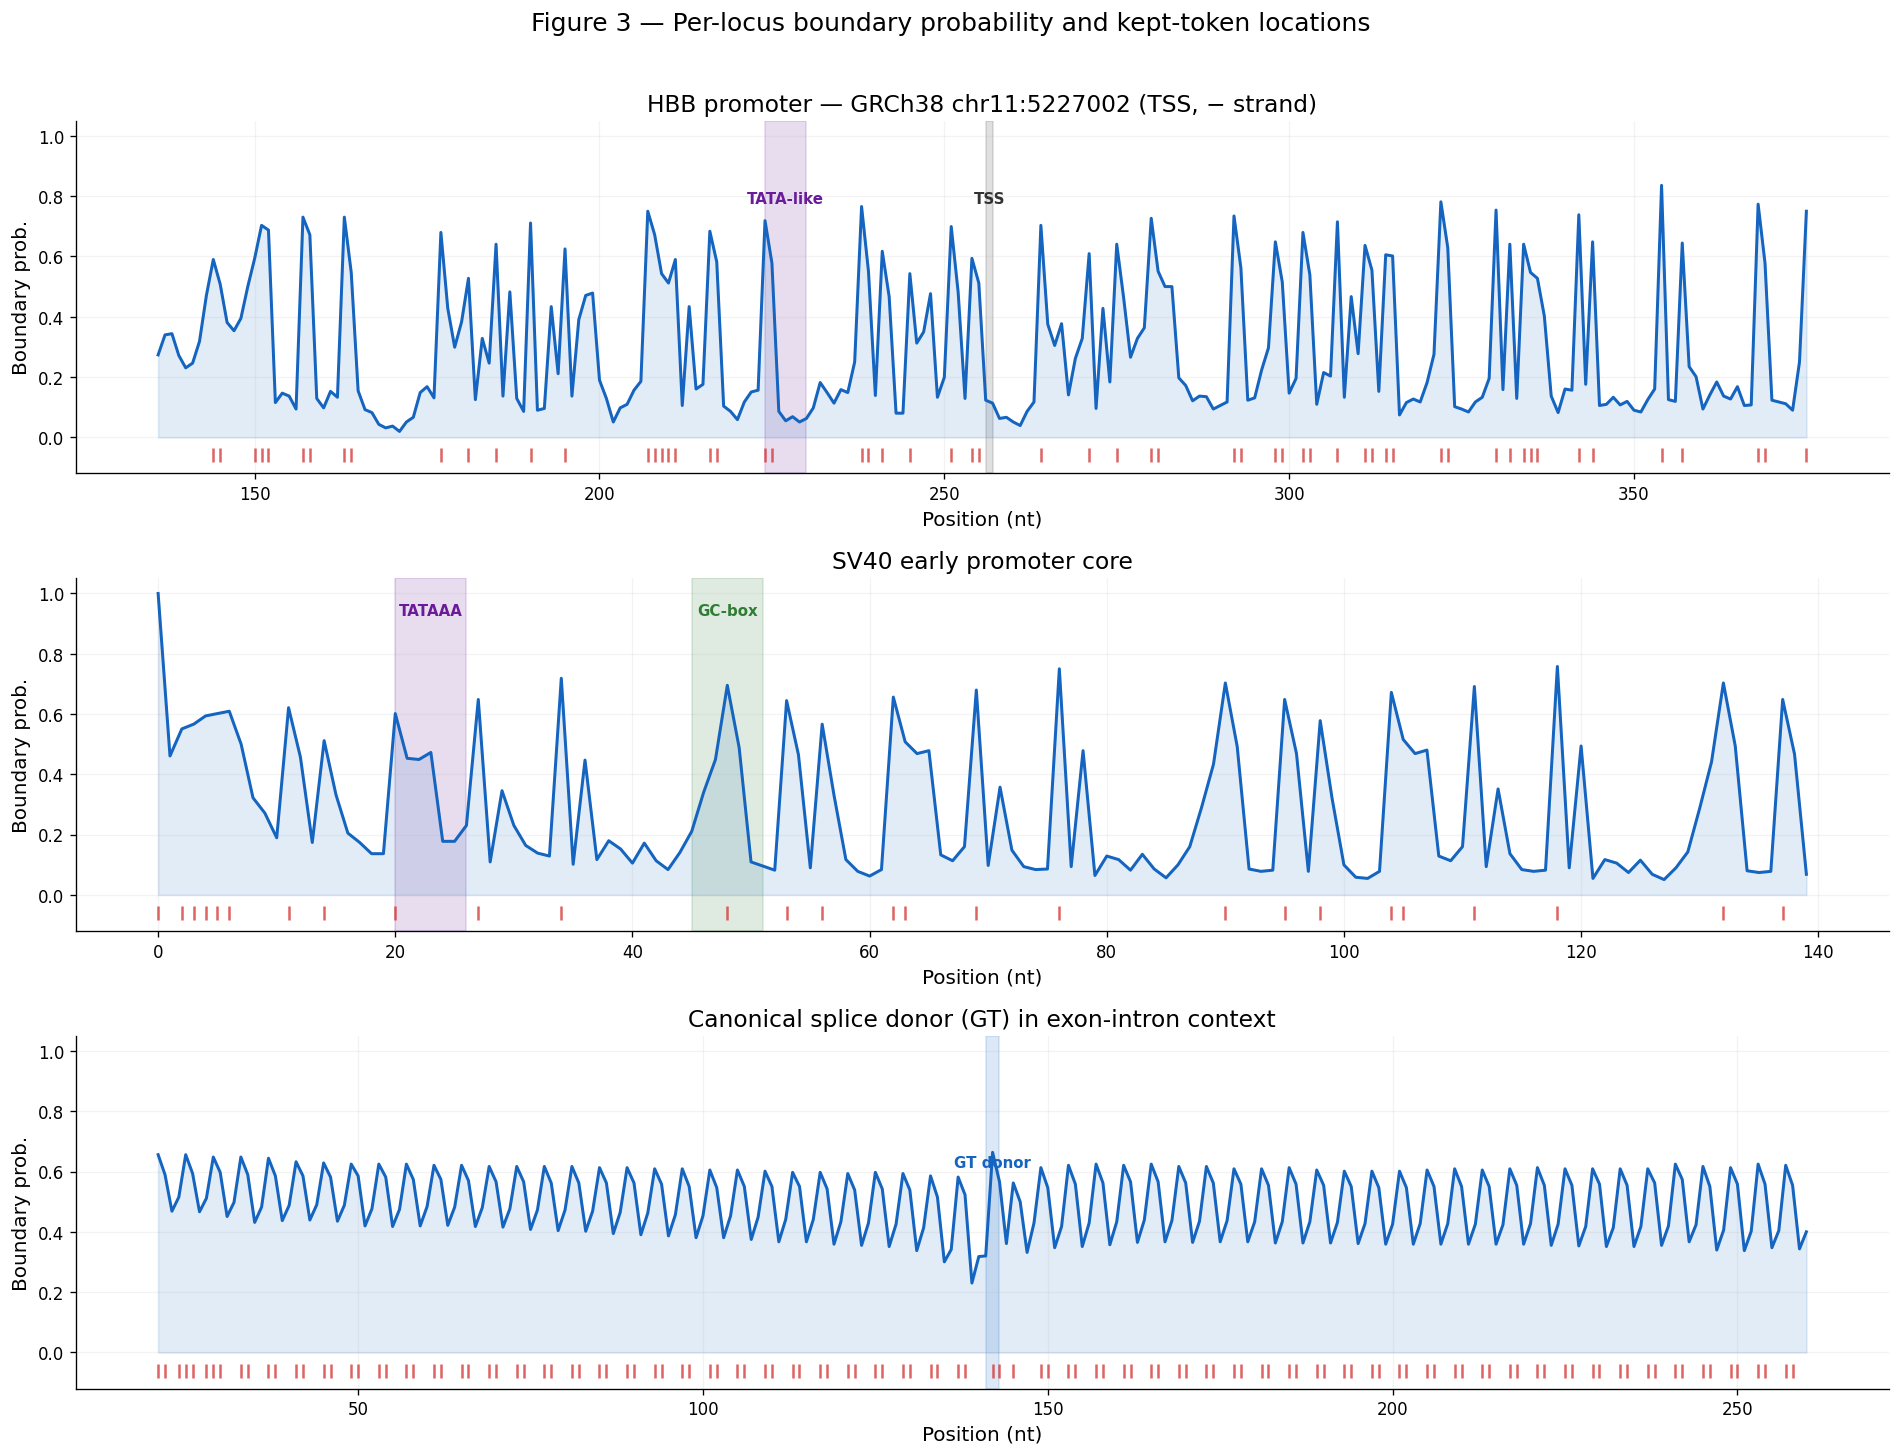

Saved fig3_curated_loci.png


In [6]:
def plot_sequence_interpretability(
    loc: AnnotatedSequence,
    zoom: Optional[Tuple[int, int]] = None,
    ax_prob=None,
    show_seq: bool = True,
):
    out = extract_boundaries(loc.sequence)
    seq, prob, bmask = out["seq"], out["prob"], out["mask"]
    L = len(seq)
    if zoom is None:
        zoom = (0, L)
    a, b = zoom
    x = np.arange(a, b)

    created = ax_prob is None
    if created:
        fig = plt.figure(figsize=(16, 4.5))
        gs = gridspec.GridSpec(2 if show_seq else 1, 1, height_ratios=[1, 0.35] if show_seq else [1])
        ax_prob = fig.add_subplot(gs[0])
        ax_seq = fig.add_subplot(gs[1], sharex=ax_prob) if show_seq else None
    else:
        ax_seq = None

    ax_prob.plot(x, prob[a:b], color=PALETTE["pos"], lw=1.8)
    ax_prob.fill_between(x, prob[a:b], alpha=0.12, color=PALETTE["pos"])
    kept = x[bmask[a:b] > 0.5]
    ax_prob.scatter(kept, np.full_like(kept, -0.06, dtype=float), marker="|", s=70,
                    color=PALETTE["kept"], alpha=0.75, zorder=4)

    for s, e, label, color in loc.annotations:
        if e < a or s > b:
            continue
        ax_prob.axvspan(max(s, a), min(e, b), alpha=0.15, color=color, zorder=0)
        ax_prob.text((s + e) / 2, ax_prob.get_ylim()[1] * 0.88, label,
                     ha="center", fontsize=9, color=color, fontweight="bold")

    ax_prob.set_ylim(-0.12, 1.05)
    ax_prob.set_ylabel("Boundary prob.")
    ax_prob.set_title(loc.name)
    ax_prob.grid(True, alpha=0.15)

    if show_seq and ax_seq is not None:
        colors = {"A": "#EF5350", "C": "#42A5F5", "G": "#FFCA28", "T": "#66BB6A", "N": "#BDBDBD"}
        for i in x:
            ax_seq.text(i, 0.5, seq[i], ha="center", va="center", fontsize=7,
                        fontfamily="monospace", color=colors.get(seq[i], "#333"))
        ax_seq.set_xlim(a - 0.5, b - 0.5)
        ax_seq.set_ylim(0, 1)
        ax_seq.set_yticks([])
        ax_seq.set_xlabel("Sequence position (nt)")

    if created:
        plt.tight_layout()
        return fig
    return ax_prob


fig, axes = plt.subplots(len(CURATED_LOCI), 1, figsize=(16, 4 * len(CURATED_LOCI)))
if len(CURATED_LOCI) == 1:
    axes = [axes]

for ax, loc in zip(axes, CURATED_LOCI):
    out = extract_boundaries(loc.sequence)
    center = loc.annotations[0][0] if loc.annotations else len(loc.sequence) // 2
    w = 120
    zoom = (max(0, center - w), min(len(loc.sequence), center + w))
    plot_sequence_interpretability(loc, zoom=zoom, ax_prob=ax, show_seq=False)
    ax.set_xlabel("Position (nt)")

fig.suptitle("Figure 3 — Per-locus boundary probability and kept-token locations", fontsize=15, y=1.01)
plt.tight_layout()
fig.savefig(os.path.join(SAVE_DIR, "fig3_curated_loci.png"))
plt.show()
print("Saved fig3_curated_loci.png")

## 6. Figure 4 — Native vs synthetic control (motif in shuffled background)

Strong interpretability control: embed the **same motif** at the same position in a **dinucleotide-shuffled** background and compare average boundary profiles.

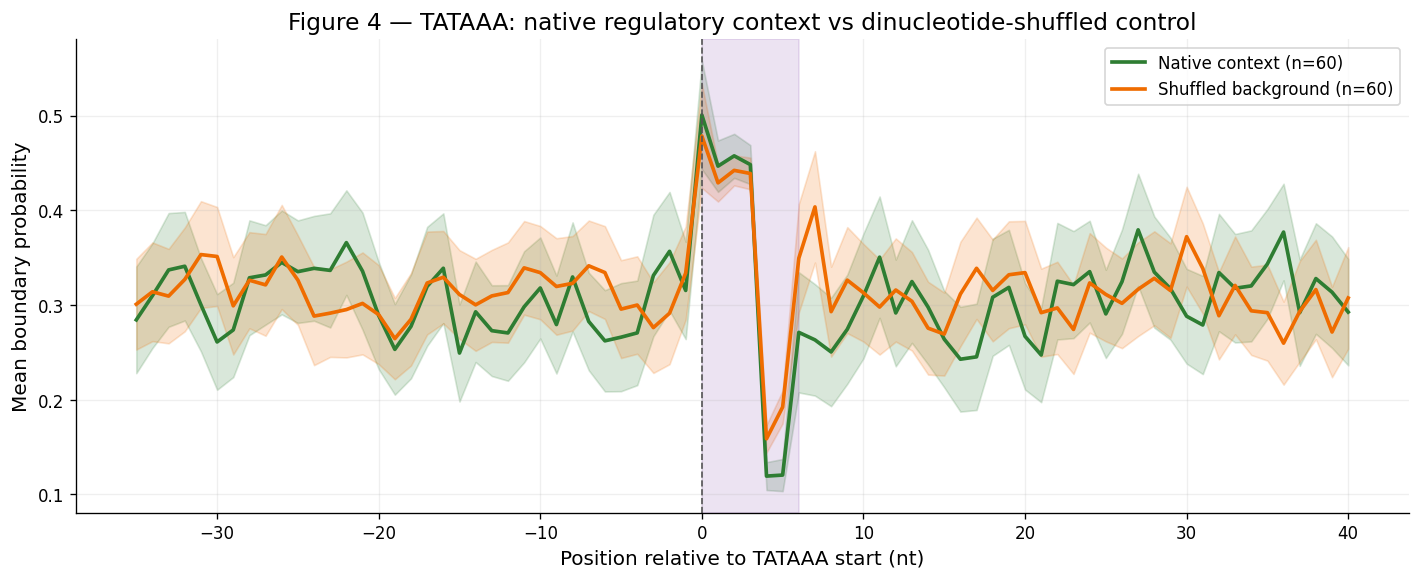

Saved fig4_native_vs_shuffled.png


In [7]:
MOTIF_CTRL = "TATAAA"
N_SYNTH = 120
rng = random.Random(SEED)

native_profiles, synth_profiles = [], []
base_seqs = build_search_pool()[:300]

for seq in base_seqs:
    for pos in find_all(seq, MOTIF_CTRL):
        native = extract_boundaries(seq)["prob"]
        W = 35
        if pos - W < 0 or pos + W + len(MOTIF_CTRL) > len(native):
            continue
        native_profiles.append(native[pos - W : pos + W + len(MOTIF_CTRL)])

        shuffled = dinucleotide_shuffle(seq, rng)
        synth_seq, new_pos = embed_motif(shuffled, MOTIF_CTRL, pos)
        synth = extract_boundaries(synth_seq)["prob"]
        if new_pos - W >= 0 and new_pos + W + len(MOTIF_CTRL) <= len(synth):
            synth_profiles.append(synth[new_pos - W : new_pos + W + len(MOTIF_CTRL)])
        if len(native_profiles) >= N_SYNTH:
            break
    if len(native_profiles) >= N_SYNTH:
        break

fig, ax = plt.subplots(figsize=(12, 5))
if native_profiles and synth_profiles:
    min_len = min(min(map(len, native_profiles)), min(map(len, synth_profiles)))
    W = 35
    x = np.arange(-W, -W + min_len)
    nat = np.stack([p[:min_len] for p in native_profiles])
    syn = np.stack([p[:min_len] for p in synth_profiles])
    for arr, color, name in [(nat, PALETTE["native"], "Native context"), (syn, PALETTE["synthetic"], "Shuffled background")]:
        m, s = arr.mean(0), arr.std(0) / np.sqrt(len(arr))
        ax.plot(x, m, color=color, lw=2.2, label=f"{name} (n={len(arr)})")
        ax.fill_between(x, m - 2 * s, m + 2 * s, color=color, alpha=0.18)
    ax.axvspan(0, len(MOTIF_CTRL), alpha=0.12, color=PALETTE["motif"])
    ax.axvline(0, color="#555", ls="--", lw=1)
    ax.legend(loc="upper right")
else:
    ax.text(0.5, 0.5, "Insufficient motif hits for control plot", ha="center", va="center", transform=ax.transAxes)

ax.set_xlabel(f"Position relative to {MOTIF_CTRL} start (nt)")
ax.set_ylabel("Mean boundary probability")
ax.set_title(f"Figure 4 — {MOTIF_CTRL}: native regulatory context vs dinucleotide-shuffled control")
ax.grid(True, alpha=0.2)
plt.tight_layout()
fig.savefig(os.path.join(SAVE_DIR, "fig4_native_vs_shuffled.png"))
plt.show()
print("Saved fig4_native_vs_shuffled.png")

## 7. Figure 5 — Boundary density (functional vs non-functional)

Fraction of positions selected as token boundaries (`boundary_mask` mean) across sequence classes.

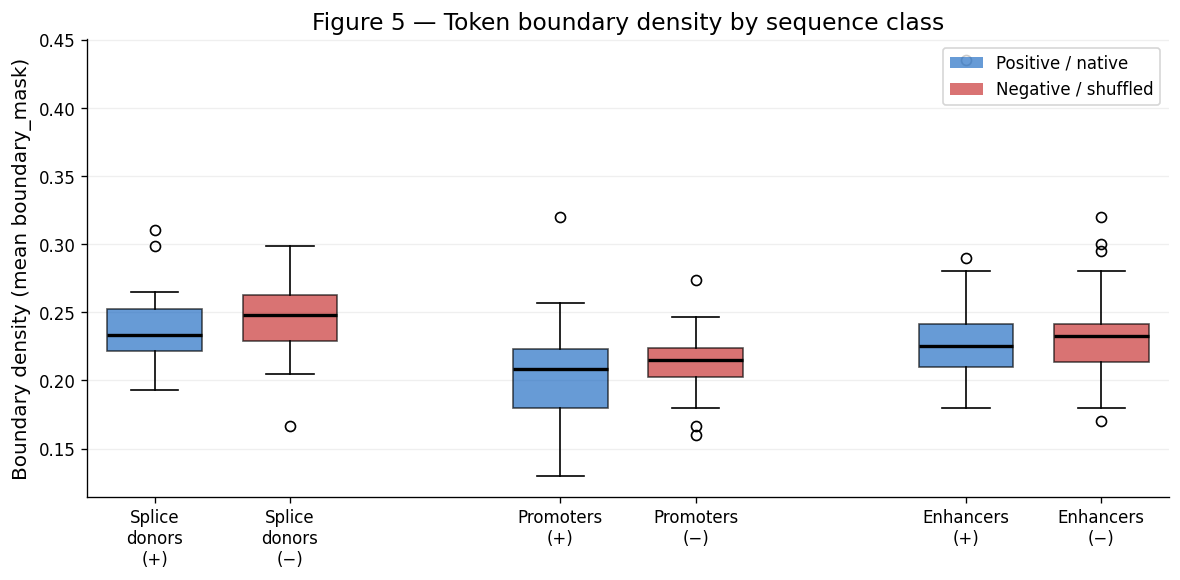

Saved fig5_boundary_density.png


In [8]:
def boundary_density(seq: str) -> float:
    return float(extract_boundaries(seq)["mask"].mean())


def densities_from_nt(task_key: str, n: int = 40) -> Tuple[List[float], List[float]]:
    ds = nt_data[task_key]["test"]
    pos = [boundary_density(ex["sequence"]) for ex in ds if ex["label"] == 1][:n]
    neg = [boundary_density(ex["sequence"]) for ex in ds if ex["label"] == 0][:n]
    return pos, neg


fig, ax = plt.subplots(figsize=(10, 5))
groups = []
if nt_data:
    task_labels = [
        ("Splice\ndonors", "splice_donor"),
        ("Promoters", "promoter_all"),
        ("Enhancers", "enhancers"),
    ]
    positions, data, colors, xticks = [], [], [], []
    for i, (label, key) in enumerate(task_labels):
        if key not in nt_data:
            continue
        pos, neg = densities_from_nt(key, n=40)
        positions.extend([i * 3, i * 3 + 1])
        data.extend([pos, neg])
        colors.extend([PALETTE["pos"], PALETTE["neg"]])
        xticks.extend([f"{label}\n(+)" , f"{label}\n(−)"])
    if data:
        bp = ax.boxplot(data, positions=positions, widths=0.7, patch_artist=True,
                        medianprops=dict(color="black", lw=2))
        for patch, color in zip(bp["boxes"], colors):
            patch.set_facecolor(color)
            patch.set_alpha(0.65)
        ax.set_xticks(positions)
        ax.set_xticklabels(xticks)
else:
    # curated-only fallback
    pos = [boundary_density(loc.sequence) for loc in CURATED_LOCI]
    rng = random.Random(SEED)
    neg = [boundary_density(dinucleotide_shuffle(loc.sequence, rng)) for loc in CURATED_LOCI]
    bp = ax.boxplot([pos, neg], labels=["Curated loci", "Shuffled control"], patch_artist=True)
    for patch, color in zip(bp["boxes"], [PALETTE["pos"], PALETTE["neg"]]):
        patch.set_facecolor(color)
        patch.set_alpha(0.65)

ax.set_ylabel("Boundary density (mean boundary_mask)")
ax.set_title("Figure 5 — Token boundary density by sequence class")
ax.legend(handles=[
    mpatches.Patch(facecolor=PALETTE["pos"], alpha=0.65, label="Positive / native"),
    mpatches.Patch(facecolor=PALETTE["neg"], alpha=0.65, label="Negative / shuffled"),
], loc="upper right")
ax.grid(True, alpha=0.2, axis="y")
plt.tight_layout()
fig.savefig(os.path.join(SAVE_DIR, "fig5_boundary_density.png"))
plt.show()
print("Saved fig5_boundary_density.png")

## 8. Optional — reference genome locus window

Uses `ldar_data/ldar_data.fa` (GRCh38, `chr11`, …) when mounted. Example: **HBB** TSS.

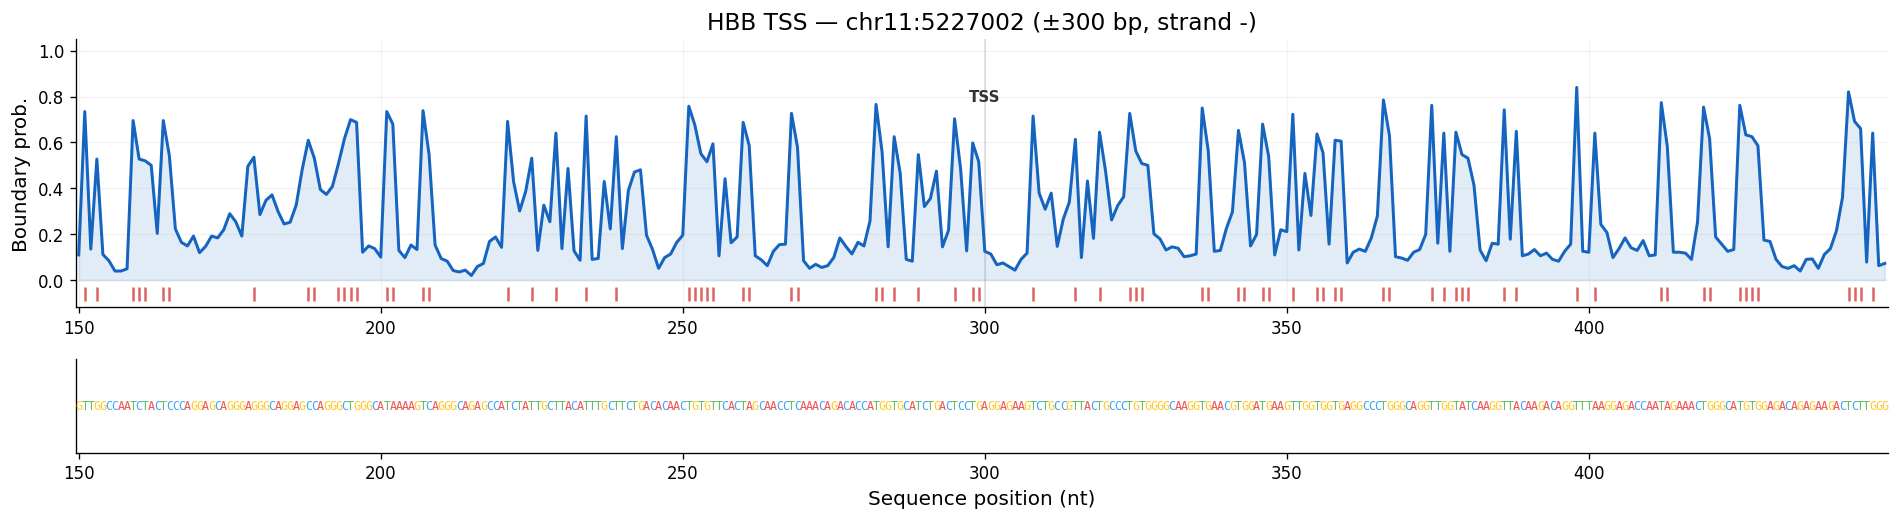

Saved fig6_hg38_locus.png  (FASTA: /workspace/ldar/ldar_data/ldar_data.fa)


In [9]:
if HG38_FASTA and os.path.isfile(HG38_FASTA):
    import pyfaidx

    fa = pyfaidx.Fasta(HG38_FASTA, as_raw=True, sequence_always_upper=True)
    chrom, tss, strand = "chr11", 5227002, "-"
    win = 600
    seq = fetch_genomic_window(fa, chrom, tss, win // 2, strand)

    loc = AnnotatedSequence(
        name=f"HBB TSS — {chrom}:{tss} (±{win//2} bp, strand {strand})",
        sequence=seq,
        annotations=[(win // 2, win // 2, "TSS", "#333")],
        source="hg38",
    )
    fig = plot_sequence_interpretability(loc, zoom=(win // 2 - 150, win // 2 + 150), show_seq=True)
    fig.savefig(os.path.join(SAVE_DIR, "fig6_hg38_locus.png"))
    plt.show()
    print(f"Saved fig6_hg38_locus.png  (FASTA: {HG38_FASTA})")
else:
    print(f"Skipping fig6 — FASTA not found: {HG38_FASTA}")

## Summary

All figures are saved under `figures/boundary_interpretability/`.

| Figure | Content |
|--------|---------|
| Fig 1 | Per-motif PNGs (`fig1_motif_tata.png`, …) + 2×2 overview |
| Fig 2 | Splice donor/acceptor junction profiles (+/−) |
| Fig 3 | Curated loci — probability + kept tokens |
| Fig 4 | Native vs dinucleotide-shuffled motif control |
| Fig 5 | Boundary density by functional class |
| Fig 6 | HBB TSS window from `ldar_data/ldar_data.fa` |

**Citing:** LDARNet (ICML 2026) — [arXiv:2606.04552](https://arxiv.org/abs/2606.04552)